# Machine Learning — Practical P02: Regression Diagnostics and Model Complexity

**Course:** Machine Learning · National University of Kyiv-Mohyla Academy (NaUKMA)  
**Instructor:** Dmytro Kuzmenko · kuzmenko@ukma.edu.ua  
**Module:** 2. Learning a Function (Regression) · **Week 2**  
**Workload:** one practical class ≈ 1.5–2 hours of active work, including discussion  
**Status:** NOT graded — practicals are skill-development and exam-preparation sessions.  
**Prerequisites:** linear regression, train/validation/test split, mean squared error

### How to work with this notebook

Every consequential task follows the loop **Experiment → Decision → Evidence → Interpretation → Counterfactual**.  
Scaffolding cells are already written and executed: read them, run them mentally, and use the printed numbers and plots as evidence.  
Empty cells are yours — they contain no model answers. The discussion questions are meant to be talked through in class.


### Learning objectives
- Read a model-complexity curve and choose a working point.
- Diagnose underfit/overfit/good fit from residual plots.
- Explain how ridge regularization and more data change the bias–variance trade-off.

## Warm-up (diagnostic)



**Warm-up 1.** Two regression models are compared on the same data split:

| Model | Train MSE | Validation MSE |
|-------|-----------|----------------|
| A     | 0.02      | 1.90           |
| B     | 0.35      | 0.45           |

Which model would you pick for deployment, and why? What do the two columns of Model A tell you?


**Your answer:**

**Warm-up 2.** You fit a *linear* regression and plot residuals (y − ŷ) against fitted values ŷ.
The points form a clear U-shape (a curve). What does that pattern say about the model?

- (a) Nothing — residuals are always noisy.
- (b) The model is overfitting.
- (c) The linear specification misses systematic structure — a sign of underfitting / wrong functional form.
- (d) The test set is too small.


**Your answer:**

**Warm-up 3.** You fit polynomials of degree 1, 2, ..., 20 to the *same fixed training set* with
ordinary least squares. As the degree grows, the **training MSE** will:

- (a) always decrease (or stay equal) — higher-degree polynomial can reproduce any lower-degree fit;
- (b) always increase;
- (c) first decrease, then increase;
- (d) stay constant.


**Your answer:**

## Guided Exercise — complexity, residuals, ridge, learning curves

Synthetic target: one real-valued feature x with a smooth nonlinear trend plus noise. We will watch the
same data through four diagnostics: the complexity curve, residual plots, the ridge path, and the
learning curve.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split

np.random.seed(42)
%matplotlib inline

rng = np.random.RandomState(42)
n = 150
x = rng.uniform(-2.0, 2.0, size=n)
y_true = x**3 - 1.2 * x**2 + 0.5 * x
y = y_true + rng.normal(0, 0.6, size=n)
X = x.reshape(-1, 1)

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"train: {len(X_tr)}, validation: {len(X_va)}")


train: 105, validation: 45


### Task 1: Model-complexity curve

**Experiment.** Fit polynomials of degree 1..12 (each with a scaler inside the pipeline) and record
train and validation MSE.


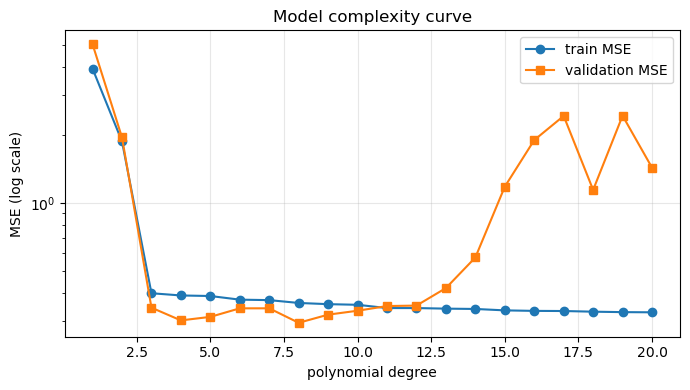

degree  1: train 3.9235 | validation 5.0340
degree  2: train 1.8700 | validation 1.9468
degree  3: train 0.3982 | validation 0.3437
degree  4: train 0.3893 | validation 0.3019
degree  5: train 0.3871 | validation 0.3130
degree  6: train 0.3730 | validation 0.3414
degree  7: train 0.3712 | validation 0.3415
degree  8: train 0.3607 | validation 0.2946
degree  9: train 0.3563 | validation 0.3201
degree 10: train 0.3540 | validation 0.3332
degree 11: train 0.3423 | validation 0.3494
degree 12: train 0.3423 | validation 0.3511
degree 13: train 0.3404 | validation 0.4197
degree 14: train 0.3392 | validation 0.5733
degree 15: train 0.3344 | validation 1.1794
degree 16: train 0.3327 | validation 1.8962
degree 17: train 0.3322 | validation 2.4250
degree 18: train 0.3300 | validation 1.1413
degree 19: train 0.3285 | validation 2.4300
degree 20: train 0.3279 | validation 1.4314


In [2]:
degrees = np.arange(1, 21)
tr_err, va_err = [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(X_tr, y_tr)
    tr_err.append(np.mean((model.predict(X_tr) - y_tr) ** 2))
    va_err.append(np.mean((model.predict(X_va) - y_va) ** 2))

plt.figure(figsize=(7, 4))
plt.plot(degrees, tr_err, "o-", label="train MSE")
plt.plot(degrees, va_err, "s-", label="validation MSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("MSE (log scale)")
plt.title("Model complexity curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for d, t, v in zip(degrees, tr_err, va_err):
    print(f"degree {d:>2}: train {t:.4f} | validation {v:.4f}")


**Evidence.** Training error keeps falling (the higher-degree polynomial can fit the noise), while
validation error bottoms out somewhere in the middle.

**Decision.** Which degree would you choose, and how exactly did you read it off the plot?
**Interpretation.** Why does validation error *increase* again after the minimum — what is the model
doing with its extra capacity?

**Counterfactual.** If the noise σ were 3× larger, predict how the position of the validation minimum
and the shape of the two curves would change.


**Your answer:**

### Task 2: Residual plots for underfit / good / overfit

**Experiment.** Fit degrees 1, 3 and 12 and plot residuals (y − ŷ) against fitted values for each.


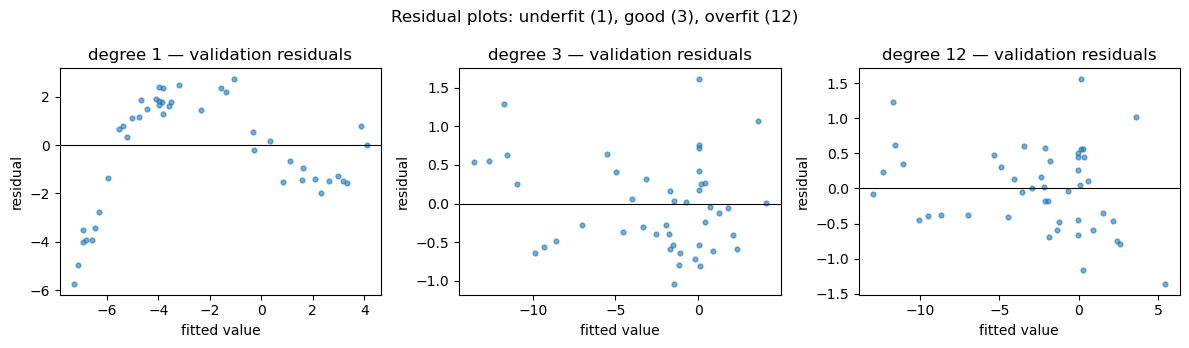

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, d in zip(axes, [1, 3, 12]):
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()).fit(X_tr, y_tr)
    pred = model.predict(X_va)
    res = y_va - pred
    ax.scatter(pred, res, s=12, alpha=0.6)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"degree {d} — validation residuals")
    ax.set_xlabel("fitted value")
    ax.set_ylabel("residual")
fig.suptitle("Residual plots: underfit (1), good (3), overfit (12)")
plt.tight_layout()
plt.show()


**Interpretation.** For each panel: is the residual band flat and symmetric around zero, or does it
show a curve / a funnel? Which degree is the best fit by this diagnostic, and does it agree with the
complexity curve from Task 1?

**Counterfactual.** If we plotted *training* residuals for degree 20 instead, what would the panel look
like, and why would that make the plot misleading?


**Your answer:**

### Task 3: Ridge — complexity under control

**Experiment.** Keep the degree-20 polynomial (it overfits), but add ridge regularization and sweep the
penalty α over many orders of magnitude.


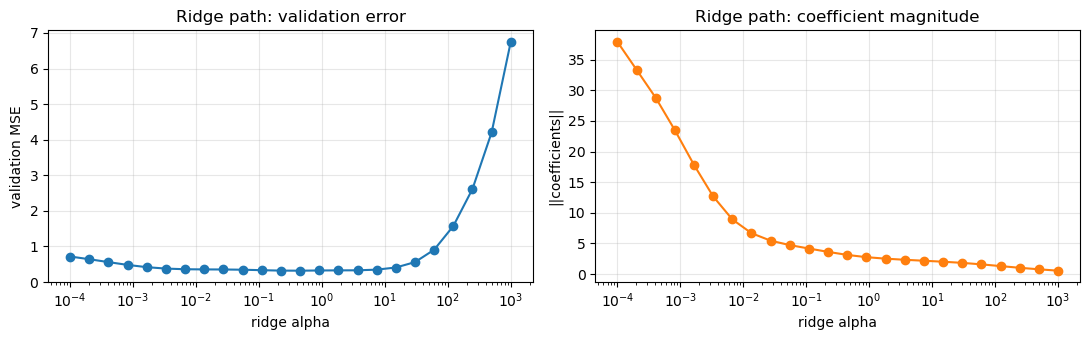

best validation MSE 0.3195 at alpha = 4.49e-01
unregularized degree-20 validation MSE (from Task 1): 1.4314


In [4]:
alphas = np.logspace(-4, 3, 24)
va_ridge, coef_norm = [], []
for a in alphas:
    model = make_pipeline(PolynomialFeatures(20), StandardScaler(), Ridge(alpha=a))
    model.fit(X_tr, y_tr)
    va_ridge.append(np.mean((model.predict(X_va) - y_va) ** 2))
    coef_norm.append(np.linalg.norm(model.named_steps["ridge"].coef_))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].semilogx(alphas, va_ridge, "o-")
axes[0].set_xlabel("ridge alpha")
axes[0].set_ylabel("validation MSE")
axes[0].set_title("Ridge path: validation error")
axes[0].grid(alpha=0.3)
axes[1].semilogx(alphas, coef_norm, "o-", color="C1")
axes[1].set_xlabel("ridge alpha")
axes[1].set_ylabel("||coefficients||")
axes[1].set_title("Ridge path: coefficient magnitude")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_a = alphas[np.argmin(va_ridge)]
print(f"best validation MSE {min(va_ridge):.4f} at alpha = {best_a:.2e}")
print(f"unregularized degree-20 validation MSE (from Task 1): {va_err[-1]:.4f}")


**Evidence.** A large α shrinks the coefficients toward zero (right panel) and, in the right range,
lowers validation error dramatically compared with plain degree-20 OLS.

**Interpretation.** Why does shrinking coefficients *help* here, and what happens to the fit if α is
pushed too far?

**Decision.** In one sentence: when would you prefer ridge over choosing a lower polynomial degree?
**Counterfactual.** Predict the effect of α → ∞ on training error and on the shape of the fitted curve.


**Your answer:**

### Task 4: Learning curve — what more data does

**Experiment.** Fix the flexible degree-8 OLS model (high capacity relative to these training sizes) and train it on growing training-set sizes
(40, 60, 80, 105 points), evaluating on the same fixed validation set.


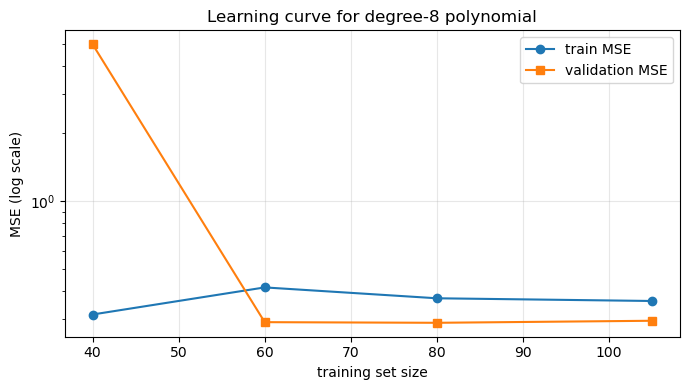

In [5]:
sizes = [40, 60, 80, 105]
lc_tr, lc_va = [], []
for s in sizes:
    Xs, ys = X_tr[:s], y_tr[:s]
    model = make_pipeline(PolynomialFeatures(8), StandardScaler(), LinearRegression()).fit(Xs, ys)
    lc_tr.append(np.mean((model.predict(Xs) - ys) ** 2))
    lc_va.append(np.mean((model.predict(X_va) - y_va) ** 2))

plt.figure(figsize=(7, 4))
plt.plot(sizes, lc_tr, "o-", label="train MSE")
plt.plot(sizes, lc_va, "s-", label="validation MSE")
plt.yscale("log")
plt.xlabel("training set size")
plt.ylabel("MSE (log scale)")
plt.title("Learning curve for degree-8 polynomial")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation.** At small n the gap is huge and the validation error is dominated by variance;
as n grows the gap shrinks. Which of the two curves is the honest one for a new deployment decision?

**Counterfactual.** Sketch (in words) how this plot would look for a *degree-2* model on the same data:
would the gap be larger or smaller, and would the validation error start higher or lower at small n?


**Your answer:**

## Discussion Questions

1. Why can training error never be used to compare models, even when it is computed on identical data?
2. A residual plot with a systematic curve means the *functional form* is wrong. If you instead saw a
   funnel shape (residual spread growing with ŷ), what would that indicate, and what fix comes to mind?
3. Ridge shrinks all coefficients. Why is that especially helpful when features are correlated
   (e.g., x, x², x³ from the same variable)?
4. "More data fixes overfitting." When is that true, and when would it fail (think of a model that is
   too simple or of irrelevant features)?
5. With 200 points and 50 features, a degree-3 polynomial expansion gives ≈ 23,400 features. Which
   number — train or validation error — would you trust, and why?
6. Your colleague reports only test MSE after trying many degrees and picking the best. What is missing
   from that report, and what should they have done instead?


## Challenge — diagnose the overfit and fix it

**Scenario.** A student fits a degree-15 polynomial by OLS to 40 noisy points from a smooth curve:
train MSE ≈ 1e-6, validation MSE is enormous. Run the snippet, then diagnose and repair.


In [6]:
rng = np.random.RandomState(11)
x_s = rng.uniform(-2, 2, 40)
y_s = np.sin(1.5 * x_s) + 0.3 * x_s + rng.normal(0, 0.25, 40)
Xs, Xs_va = x_s.reshape(-1, 1), np.linspace(-2, 2, 400).reshape(-1, 1)

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, y_s, test_size=0.25, random_state=42)
overfit = make_pipeline(PolynomialFeatures(15), StandardScaler(), LinearRegression()).fit(Xs_tr, ys_tr)
print(f"train MSE:   {np.mean((overfit.predict(Xs_tr) - ys_tr) ** 2):.2e}")
print(f"test MSE:    {np.mean((overfit.predict(Xs_te) - ys_te) ** 2):.3f}")


train MSE:   2.07e-02
test MSE:    0.199


**Your task (diagnosis + two fixes).**
1. Name the failure mode and the exact evidence in the two numbers above.
2. Propose **two** different fixes (they may be: lower degree; ridge; more data; better split).
3. For each fix, **predict** (counterfactual) what happens to train MSE, to test MSE, and to the gap.
4. Implement one of the fixes in the code cell and check whether your prediction held.

Use the empty code cell for your experiment and the markdown cell for the diagnosis.


In [7]:
# Your code here — implement one fix and compare with the overfit numbers above


**Your answer (diagnosis and predictions):**

## Takeaways

- The complexity curve (train vs validation error as capacity grows) is the standard way to choose a
  working point; train error alone is useless.
- Residual plots reveal *what kind* of mistake the model makes: curves → wrong functional form
  (underfit), growing spread → heteroscedasticity, huge scatter everywhere → overfit/noise fitting.
- The train–validation gap quantifies overfitting; validation error quantifies the bias–variance
  balance.
- Ridge trades a little bias for a lot of variance: it controls the complexity of a high-capacity
  model without changing its structure.
- Learning curves show how the gap closes as n grows — the honest estimator of "what more data buys".
- Always report the split protocol: preprocessing fitted on train only, validation kept out of every
  modeling decision.
